# Financial Econometrics — Homework 1
**Solved by: Cyril Gabriele, Adriano Lama**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
from homework01_cleanup import (
    monthly_log_return, wti_plots, testing_avg_ret_stoxx,
    testing_CI_avg_ret_gold, correlation_matrix_risky_assets,
    highest_kurtoisis, plot_kutosis_vs_normal, highest_jarque_bera,
    hike_cut_identification, label_hiking_months, analyze_monetary_regimes
)

## 1. Import Data

In [3]:
df = pd.read_csv("./s1_data_hw.csv", encoding="utf-8-sig")
df.head()

,Date,SXXP Index,SPY US INDEX,NKY INDEX,XAU CURNCY,CL1 COMDTY,SPDIV,RF,DFEDTARU
0,12/31/08,276.76878,90.24,98.07993,875.43,44.60,28.390000,2.87,0.25
1,1/30/09,245.27160,82.83,88.89192,927.85,41.68,28.013333,3.02,0.25
2,2/27/09,219.88507,73.93,77.26031,942.32,44.76,27.636667,2.71,0.25
3,3/31/09,233.43893,79.52,81.62587,919.90,49.66,27.260000,3.16,0.25
4,4/30/09,264.48381,87.42,89.27354,887.95,51.12,26.703333,3.47,0.25


## 2. Monthly Log Returns (from Jan 2011)

In [4]:
monthly_returns, df_adjusted = monthly_log_return(df)
monthly_returns.head()

Mean monthly log return STOXX600: 0.0033
Mean monthly log return NIKKEI: 0.0053


,Date,RF_monthly,SP500_monthly_log_return,STOXX600_monthly_log_return,NIKKEI_monthly_log_return,GOLD_monthly_log_return,WTI_monthly_log_return
0,2011-02-28,0.002892,0.034148,0.029578,0.038491,0.054389,0.050550
1,2011-03-31,0.002767,-0.004215,-0.009147,-0.097236,0.018178,0.095807
2,2011-04-29,0.002542,0.028550,0.072006,0.025106,0.083955,0.065376
3,2011-05-31,0.002650,-0.011278,-0.041080,-0.013265,-0.017723,-0.103772
4,2011-06-30,0.002350,-0.021959,-0.019705,0.022179,-0.020725,-0.073524


## 3. WTI Price & Return Plots

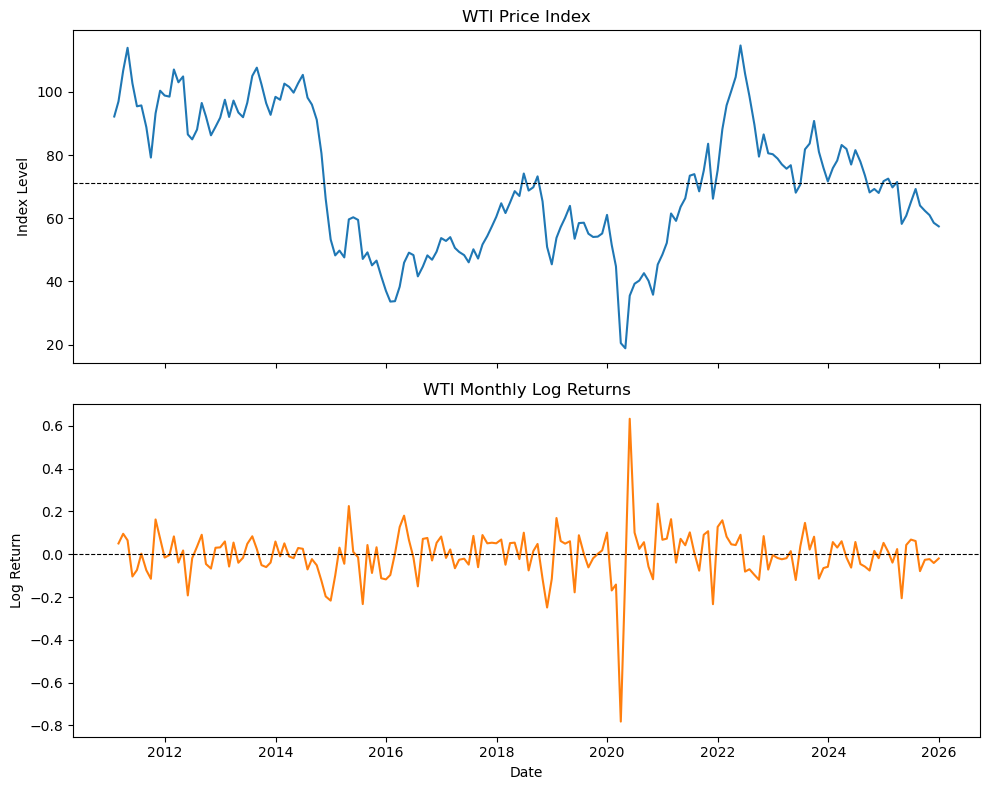

WTI returns show a pronounced spike of -78.19% around Mar 2020, highlighting their volatility.



In [5]:
wti_plots(df_adjusted)

## 4. Hypothesis Test — STOXX600 Mean Return

In [6]:
testing_avg_ret_stoxx(monthly_returns)

t-statistic: 0.9383
p-value: 0.3494
FAILED TO REJECT H_0


## 5. 95% Confidence Interval — GOLD Mean Return

In [7]:
testing_CI_avg_ret_gold(monthly_returns)

95% CI lower bound: -0.0000
95% CI upper bound: 0.0131
Average monthly risk-free rate: 0.0021
Cannot claim Gold outperformed the risk-free rate at the 95% confidence level.


## 6. Correlation Matrix

In [8]:
correlation_matrix = correlation_matrix_risky_assets(monthly_returns)
correlation_matrix

,SP500_monthly_log_return,STOXX600_monthly_log_return,NIKKEI_monthly_log_return,GOLD_monthly_log_return,WTI_monthly_log_return
SP500_monthly_log_return,1.000000,0.818309,0.713322,0.104270,0.403008
STOXX600_monthly_log_return,0.818309,1.000000,0.693694,0.225107,0.441471
NIKKEI_monthly_log_return,0.713322,0.693694,1.000000,0.036815,0.296982
GOLD_monthly_log_return,0.104270,0.225107,0.036815,1.000000,0.032157
WTI_monthly_log_return,0.403008,0.441471,0.296982,0.032157,1.000000


In [9]:
wti_max_corr = (
    correlation_matrix["WTI_monthly_log_return"]
    .drop("WTI_monthly_log_return")
    .idxmax()
)
print(f"WTI most correlated with: {wti_max_corr}")

sp500_max_corr = (
    correlation_matrix["SP500_monthly_log_return"]
    .drop("SP500_monthly_log_return")
    .idxmax()
)
print(f"SP500 most correlated with: {sp500_max_corr}")

WTI most correlated with: STOXX600_monthly_log_return
SP500 most correlated with: STOXX600_monthly_log_return


## 7. Excess Kurtosis

In [10]:
asset_name_max_kurt, value_max_kurt = highest_kurtoisis(monthly_returns)
print(f"Highest excess kurtosis: {asset_name_max_kurt} = {value_max_kurt:.4f}")

Highest excess kurtosis: WTI_monthly_log_return = 15.6302


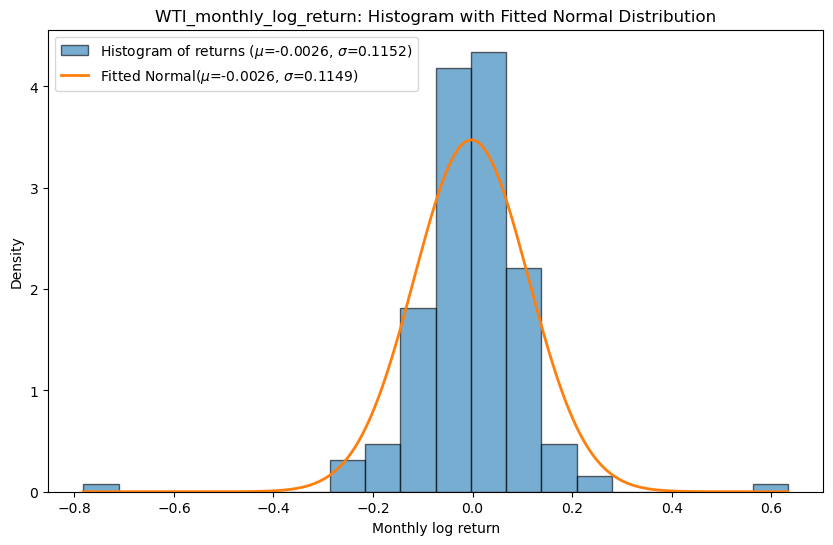

In [11]:
plot_kutosis_vs_normal(monthly_returns, asset_name_max_kurt)

## 8. Jarque-Bera Test

In [12]:
asset_jb, stat_jb, pval_jb = highest_jarque_bera(monthly_returns)
print(f"Farthest from normal: {asset_jb}")
print(f"JB statistic: {stat_jb:.4f}, p-value: {pval_jb}")

Farthest from normal: WTI_monthly_log_return
JB statistic: 1739.7922, p-value: 0.0


## 9. Federal Reserve Hiking Cycles

### 9a) Identify hiking-cycle months

In [13]:
df_hike_cut = hike_cut_identification(df)
df_cycles = label_hiking_months(df_hike_cut)

num_hiking_months = (df_cycles["D_t"] == 1).sum()
print(f"Total hiking-cycle months (sum of D_t): {num_hiking_months}")

Total hiking-cycle months (sum of D_t): 81


### 9b–e) Total Return, Hiking vs Easing, Two-Sample t-Test

In [14]:
df_regimes = analyze_monetary_regimes(df, df_cycles)


--- Question 9 ---
9(b) Std Dev of SP500 Total Return: 0.0435
9(c) Hiking Cycles -> Mean: 0.0269, IQR: 0.0416
9(d) Easing/Pause Cycles -> Mean: 0.0262, IQR: 0.0552
9(e) t-test -> t-statistic: 0.1173, p-value: 0.9067
     Result: Fail to reject H_0. Returns are NOT significantly different at the 5% level.
